### Cybersecurity Threat Analysis and Intrusion Detection Using Machine Learning (2015–2024)

**Prepared By: Olumide Johnson Ikumapayi**

#### Project Overview

This project focuses on analyzing global cybersecurity incidents using machine learning to identify patterns in malware distribution, cyberattack vectors, targeted industries, and impacted countries. The goal is to develop models that can help predict the likelihood or type of future cyber threats and support real-time threat monitoring and intrusion detection systems (IDS). The insights can help organizations and security professionals prioritize defenses, allocate resources, and mitigate future risks.

**Key Goals:**

•	Analyze historical cybersecurity incidents and their attributes.
•	Detect and classify different types of cyber threats.
•	Identify high-risk industries, regions, and malware behaviors.
•	Use ML models to classify or predict threat categories.

**About the Dataset**

This dataset aggregates real-world and simulated data about cybersecurity incidents from 2015 to 2024. It includes attributes such as threat types, malware names, attack vectors, targeted sectors, country of origin, and the impact level. It is particularly valuable for threat intelligence, IDS research, and anomaly detection models.Here is a link to the dataset on Kaggle public repository: https://www.kaggle.com/datasets/atharvasoundankar/global-cybersecurity-threats-2015-2024


The flow of the **Global Cybersecurity Threat** dataset is as follows:

1. [Project Setup & Libraries](#Project-Setup-&-Libraries)
2. [Data Acquisition & Initial Inspection](#Data-Acquisition-&-Initial-Inspection)
3. [Data Cleaning & Missing Values](#Data-Cleaning-&-Missing-Values)
4. [Description of the Dataset](#Description-of-the-Dataset)
5. [Exploratory Data Analysis (EDA)](#Exploratory-Data-Analysis-(EDA))
6. [Correlation Analysis](#Correlation-Analysis)
7. [Feature Engineering & Preprocessing](#Feature-Engineering-&-Preprocessing)
8. [Handling imbalanced target variable Using SMOTE](#Handling-imbalanced-target-variable-Using-SMOTE)
9. [Machine Learning Models](#Machine-Learning-Models)
10.[Summary and Conclusion](#Summary-and-Conclusion)

### Project Setup & Libraries

In [1]:
# Standard Library
import warnings
warnings.filterwarnings('ignore')

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Preprocessing & Feature Engineering
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder, label_binarize
from sklearn.impute import SimpleImputer

# Model Selection
from sklearn.model_selection import train_test_split

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTE, SMOTENC

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    auc,
    RocCurveDisplay,
    plot_roc_curve
)

### Data Acquisition & Initial Inspection

#### Loading the dataset

In [2]:
df_Global_Cybersecurity_Threats_2015_2024_Dataset = pd.read_csv('Global_Cybersecurity_Threats_2015-2024.csv')
df_Global_Cybersecurity_Threats_2015_2024_Dataset.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


In [3]:
df_Global_Cybersecurity_Threats_2015_2024_Dataset.tail()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
2995,UK,2021,Ransomware,Government,51.42,190694,Unknown,Social Engineering,Firewall,52
2996,Brazil,2023,SQL Injection,Telecommunications,30.28,892843,Hacker Group,Zero-day,VPN,26
2997,Brazil,2017,SQL Injection,IT,32.97,734737,Nation-state,Weak Passwords,AI-based Detection,30
2998,UK,2022,SQL Injection,IT,32.17,379954,Insider,Unpatched Software,Firewall,9
2999,Germany,2021,SQL Injection,Retail,48.20,480984,Unknown,Zero-day,VPN,64


**Inspecting shape, column, types, missing values and Other Basic Statistics**

In [4]:
# Checking the dataset dimension
df_Global_Cybersecurity_Threats_2015_2024_Dataset.shape

(3000, 10)

The dataset contains 3,000 rows and 10 columns.Of which 1 is target variable and the remaining 9 are independent varbiables.

Below are the structure of the attributes:

**Feature Name/Description**

* **country**: Country affected by the attack
* **year**: Year of incident (2015–2024)                              
* **Attack Type**: Type of attack (e.g., DDoS, Phishing, Malware, Ransomware)
* **Target Industry**: Industry sector targeted (e.g., Finance, Healthcare, Government)                        
* **Financial Loss (in Million $)**: Estimated financial damage caused by the incident
* **Number of Affected Users**: Total number of users impacted by the attack.
* **Attack Source**: Origin of the attack (e.g., insider, external actor, or nation-state)
* **Security Vulnerability Type**: Weakness exploited (e.g., unpatched software, weak passwords, or misconfiguration)
* **Defense Mechanism Used**: Security control applied (e.g, firewall, antivirus, encryption, or intrusion detection)

**Target variable** : Attack Type

In [5]:
# Check column of the dataset
df_Global_Cybersecurity_Threats_2015_2024_Dataset.columns

Index(['Country', 'Year', 'Attack Type', 'Target Industry',
       'Financial Loss (in Million $)', 'Number of Affected Users',
       'Attack Source', 'Security Vulnerability Type',
       'Defense Mechanism Used', 'Incident Resolution Time (in Hours)'],
      dtype='object')

In [6]:
# checking the types of columns
df_Global_Cybersecurity_Threats_2015_2024_Dataset.dtypes

Country                                 object
Year                                     int64
Attack Type                             object
Target Industry                         object
Financial Loss (in Million $)          float64
Number of Affected Users                 int64
Attack Source                           object
Security Vulnerability Type             object
Defense Mechanism Used                  object
Incident Resolution Time (in Hours)      int64
dtype: object

We have three(3) different types of data present in the dataset i.e. object,int64 and float64.

In [7]:
# Checking the column info
df_Global_Cybersecurity_Threats_2015_2024_Dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              3000 non-null   object 
 1   Year                                 3000 non-null   int64  
 2   Attack Type                          3000 non-null   object 
 3   Target Industry                      3000 non-null   object 
 4   Financial Loss (in Million $)        3000 non-null   float64
 5   Number of Affected Users             3000 non-null   int64  
 6   Attack Source                        3000 non-null   object 
 7   Security Vulnerability Type          3000 non-null   object 
 8   Defense Mechanism Used               3000 non-null   object 
 9   Incident Resolution Time (in Hours)  3000 non-null   int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 234.5+ KB


As shown here are the features of the dataset,which includes indexing type,column type,non null values and memory usage.As shown, there are no Null/missing values in the 3000 dataset.

### Data Cleaning & Missing Values

**Handling null, missing and inconsistent data**

In [8]:
# checking null values
df_Global_Cybersecurity_Threats_2015_2024_Dataset.isnull().sum()

Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (in Million $)          0
Number of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (in Hours)    0
dtype: int64

<AxesSubplot:>

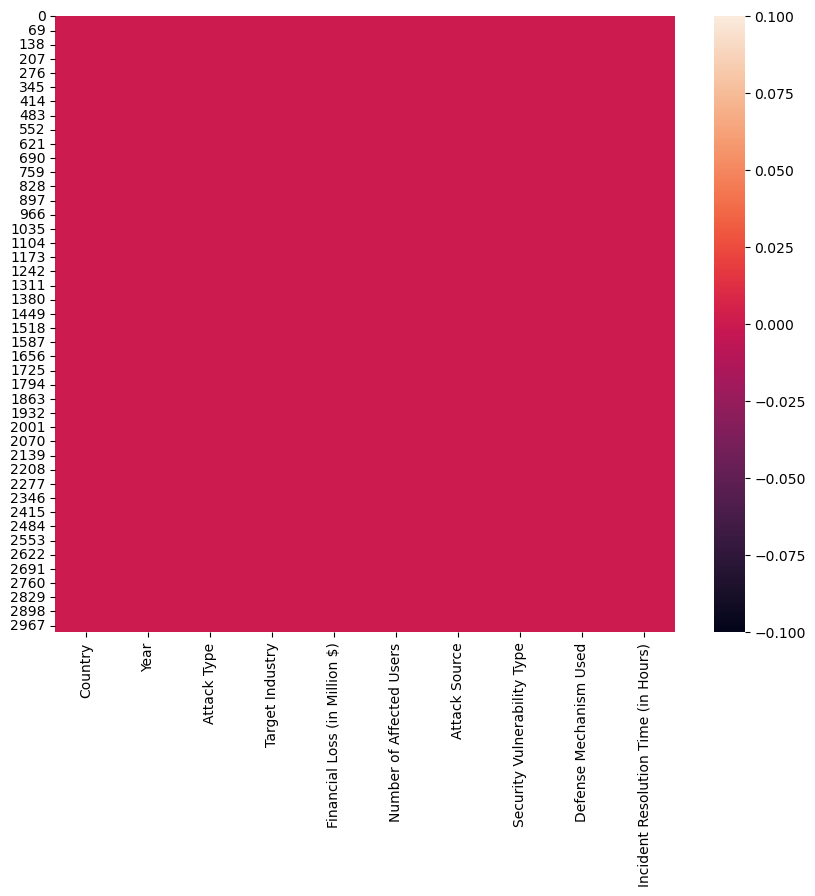

In [9]:
# Visualize with heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df_Global_Cybersecurity_Threats_2015_2024_Dataset.isnull())

The heatmap confirms that the dataset has **no missing values** across all variables and records, indicating a complete and clean dataset, meaning that the data is ready for analysis and classification.

In [10]:
# Checking the unique values of objects-column
for col in df_Global_Cybersecurity_Threats_2015_2024_Dataset.select_dtypes(include='object').columns:
    print(col)
    print(df_Global_Cybersecurity_Threats_2015_2024_Dataset[col].unique())

Country
['China' 'India' 'UK' 'Germany' 'France' 'Australia' 'Russia' 'Brazil'
 'Japan' 'USA']
Attack Type
['Phishing' 'Ransomware' 'Man-in-the-Middle' 'DDoS' 'SQL Injection'
 'Malware']
Target Industry
['Education' 'Retail' 'IT' 'Telecommunications' 'Government' 'Banking'
 'Healthcare']
Attack Source
['Hacker Group' 'Nation-state' 'Insider' 'Unknown']
Security Vulnerability Type
['Unpatched Software' 'Weak Passwords' 'Social Engineering' 'Zero-day']
Defense Mechanism Used
['VPN' 'Firewall' 'AI-based Detection' 'Antivirus' 'Encryption']


In [11]:
# Finding number of unique values in the column
df_Global_Cybersecurity_Threats_2015_2024_Dataset.nunique().to_frame("No.of unique values")

,No.of unique values
Country,10
Year,10
Attack Type,6
Target Industry,7
Financial Loss (in Million $),2536
Number of Affected Users,2998
Attack Source,4
Security Vulnerability Type,4
Defense Mechanism Used,5
Incident Resolution Time (in Hours),72


All the features have more than one single values.

In [12]:
# Checking the list of counts of target
df_Global_Cybersecurity_Threats_2015_2024_Dataset["Attack Type"].unique()

array(['Phishing', 'Ransomware', 'Man-in-the-Middle', 'DDoS',
       'SQL Injection', 'Malware'], dtype=object)

In [13]:
# Checking the unique values in target column
df_Global_Cybersecurity_Threats_2015_2024_Dataset['Attack Type'].value_counts()

DDoS                 531
Phishing             529
SQL Injection        503
Ransomware           493
Malware              485
Man-in-the-Middle    459
Name: Attack Type, dtype: int64

As shown in the above distribution, The most frequently attacked in line with the type of attack is the  **DDoS** with **531 cases**, followed closely by **Phishing** with **529**, **SQL Injection** has **503** attacks,**Ransomware** had **493**, and **Malware** with **485**, while **Man-in-the-Middle** is the least common with **459 cases**. 

### Description of the Dataset

In [14]:
# Statistical summary of numerical columns
df_Global_Cybersecurity_Threats_2015_2024_Dataset.describe()

,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2019.570333,50.492970,504684.136333,36.476000
std,2.857932,28.791415,289944.084972,20.570768
min,2015.000000,0.500000,424.000000,1.000000
25%,2017.000000,25.757500,255805.250000,19.000000
50%,2020.000000,50.795000,504513.000000,37.000000
75%,2022.000000,75.630000,758088.500000,55.000000
max,2024.000000,99.990000,999635.000000,72.000000


**The above gives us statistical information of the numerical columns.The summary of the dataset looks good since there are no negative(-ve)/invalid values present.**

from the above description, we can observe the following-:
1. The counts of all the columns are the same which means there are no missing values in the dataset.
2. The mean value is slightly greater than the median(50%) in the **Number of affected users** column which means the data is skewed to right in these column.
3. The data in the  **Financial Loss** and **Incident Resolution Time** columns have mean value less than median which means the data is skewed to left.
4. Summarizing the data, we can observe there is are differences between 75% and max hence there are outliers present in the data.
5. We can also notice the Standard deviation,min,25% percentile from the data.  

In [15]:
# Lets also check the statistical distribution for numerical features
df_Global_Cybersecurity_Threats_2015_2024_Dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,3000.0,2019.570333,2.857932,2015.0,2017.0000,2020.000,2022.00,2024.00
Financial Loss (in Million $),3000.0,50.492970,28.791415,0.5,25.7575,50.795,75.63,99.99
Number of Affected Users,3000.0,504684.136333,289944.084972,424.0,255805.2500,504513.000,758088.50,999635.00
Incident Resolution Time (in Hours),3000.0,36.476000,20.570768,1.0,19.0000,37.000,55.00,72.00


### Exploratory Data Analysis (EDA)

**Univariate Analysis**

In [16]:
# The number Reports by the Attack Type 
print(df_Global_Cybersecurity_Threats_2015_2024_Dataset['Attack Type'].value_counts())

DDoS                 531
Phishing             529
SQL Injection        503
Ransomware           493
Malware              485
Man-in-the-Middle    459
Name: Attack Type, dtype: int64


In [17]:
# The % rate of Reports by the Authority
target_df=df_Global_Cybersecurity_Threats_2015_2024_Dataset['Attack Type'].value_counts()*100/df_Global_Cybersecurity_Threats_2015_2024_Dataset.shape[0]
target_df

DDoS                 17.700000
Phishing             17.633333
SQL Injection        16.766667
Ransomware           16.433333
Malware              16.166667
Man-in-the-Middle    15.300000
Name: Attack Type, dtype: float64

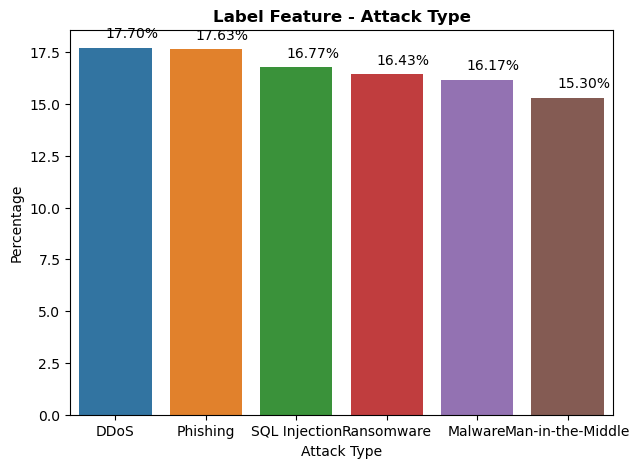

In [18]:
plt.figure(figsize=(7,5))
plt.title("Label Feature - Attack Type",fontdict={'fontweight':'bold','fontsize':12})
ax=sns.barplot(x=target_df.index,y=target_df.values)
plt.xlabel('Attack Type')
plt.ylabel('Percentage')

for p in ax.patches:
    height=p.get_height()
    width=p.get_width()
    x,_=p.get_xy()
    ax.text(x+width/2.8,height+0.5,f'{height:.2f}%')

In the above distribution of **Attack Type**, **DDoS** has the largest proportion at **17.70%**, followed very closely by **Phishing** at **17.63%**. **SQL** Injection accounts for **16.77%**, while **Ransomware** contributes **16.43%** and **Malware** makes up **16.17%** of the observations. **Man-in-the-Middle** has the smallest share at **15.30%**, closer in proportion to the other classes.

In [19]:
# Lets Separate the numerical from categorical columns

# check out the categorical columns
categorical_col = []
for i in df_Global_Cybersecurity_Threats_2015_2024_Dataset.dtypes.index:
    if df_Global_Cybersecurity_Threats_2015_2024_Dataset.dtypes[i] == "object":
        categorical_col.append(i)
print("categorical columns:", categorical_col)
print("\n")

# Check for Numerical column
numerical_col = []
for i in df_Global_Cybersecurity_Threats_2015_2024_Dataset.dtypes.index:
    if df_Global_Cybersecurity_Threats_2015_2024_Dataset.dtypes[i]!= "object":
        numerical_col.append(i)
print("numerical columns:", numerical_col)

categorical columns: ['Country', 'Attack Type', 'Target Industry', 'Attack Source', 'Security Vulnerability Type', 'Defense Mechanism Used']


numerical columns: ['Year', 'Financial Loss (in Million $)', 'Number of Affected Users', 'Incident Resolution Time (in Hours)']


UK           321
Brazil       310
India        308
France       305
Japan        305
Australia    297
Russia       295
Germany      291
USA          287
China        281
Name: Country, dtype: int64


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'UK'),
  Text(1, 0, 'Brazil'),
  Text(2, 0, 'India'),
  Text(3, 0, 'France'),
  Text(4, 0, 'Japan'),
  Text(5, 0, 'Australia'),
  Text(6, 0, 'Russia'),
  Text(7, 0, 'Germany'),
  Text(8, 0, 'USA'),
  Text(9, 0, 'China')])

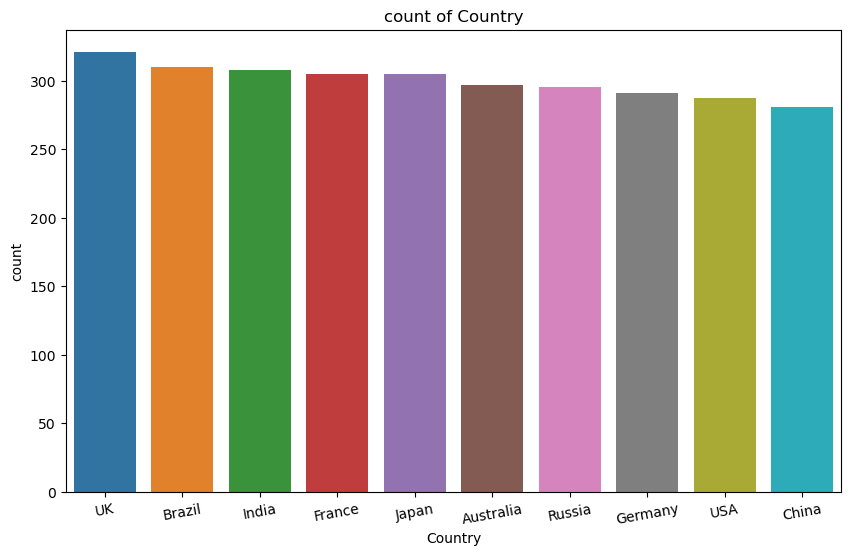

In [20]:
# Visualizing the count of Country
plt.figure(figsize=(10,6))
sns.countplot(df_Global_Cybersecurity_Threats_2015_2024_Dataset['Country'],order=df_Global_Cybersecurity_Threats_2015_2024_Dataset['Country'].value_counts().index)
plt.title('count of Country')
print(df_Global_Cybersecurity_Threats_2015_2024_Dataset['Country'].value_counts())
plt.xticks(rotation=10)

The distribution of Country is fairly balanced across the dataset, with only small differences in the number of recorded incidents among countries. The UK has the highest count with 321 cases, followed by Brazil with 310 and India with 308. France and Japan each account for 305 cases, while Australia records 297, Russia 295, and Germany 291. The USA has 287 cases, and China has the lowest count at 281.

DDoS                 531
Phishing             529
SQL Injection        503
Ransomware           493
Malware              485
Man-in-the-Middle    459
Name: Attack Type, dtype: int64


(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'DDoS'),
  Text(1, 0, 'Phishing'),
  Text(2, 0, 'SQL Injection'),
  Text(3, 0, 'Ransomware'),
  Text(4, 0, 'Malware'),
  Text(5, 0, 'Man-in-the-Middle')])

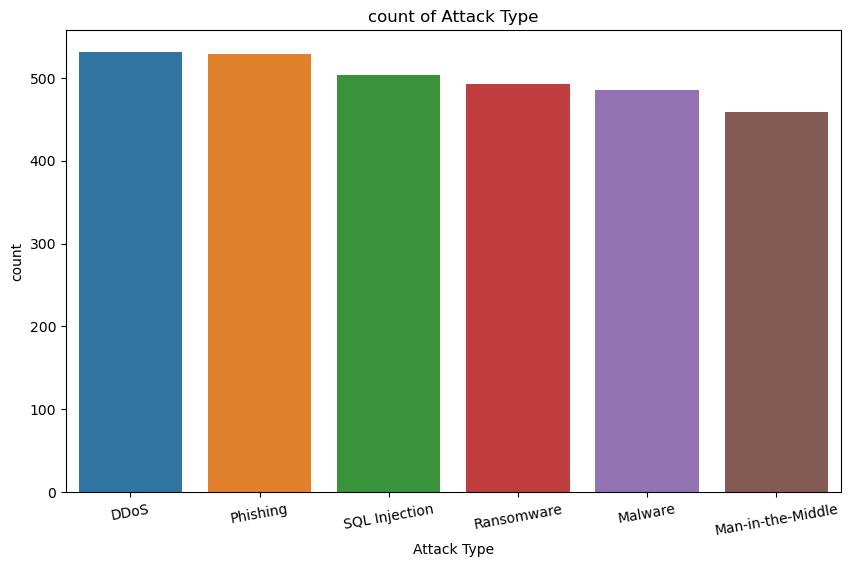

In [21]:
# Visualizing the count of Attack Type
plt.figure(figsize=(10,6))
sns.countplot(df_Global_Cybersecurity_Threats_2015_2024_Dataset['Attack Type'],order=df_Global_Cybersecurity_Threats_2015_2024_Dataset['Attack Type'].value_counts().index)
plt.title('count of Attack Type')
print(df_Global_Cybersecurity_Threats_2015_2024_Dataset['Attack Type'].value_counts())
plt.xticks(rotation=10)

The distribution of Country is fairly balanced across the dataset, with only small differences in the number of recorded incidents among countries. The UK has the highest count with 321 cases, followed by Brazil with 310 and India with 308. France and Japan each account for 305 cases, while Australia records 297, Russia 295, and Germany 291. The USA has 287 cases, and China has the lowest count at 281.

IT                    478
Banking               445
Healthcare            429
Retail                423
Education             419
Telecommunications    403
Government            403
Name: Target Industry, dtype: int64


(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'IT'),
  Text(1, 0, 'Banking'),
  Text(2, 0, 'Healthcare'),
  Text(3, 0, 'Retail'),
  Text(4, 0, 'Education'),
  Text(5, 0, 'Telecommunications'),
  Text(6, 0, 'Government')])

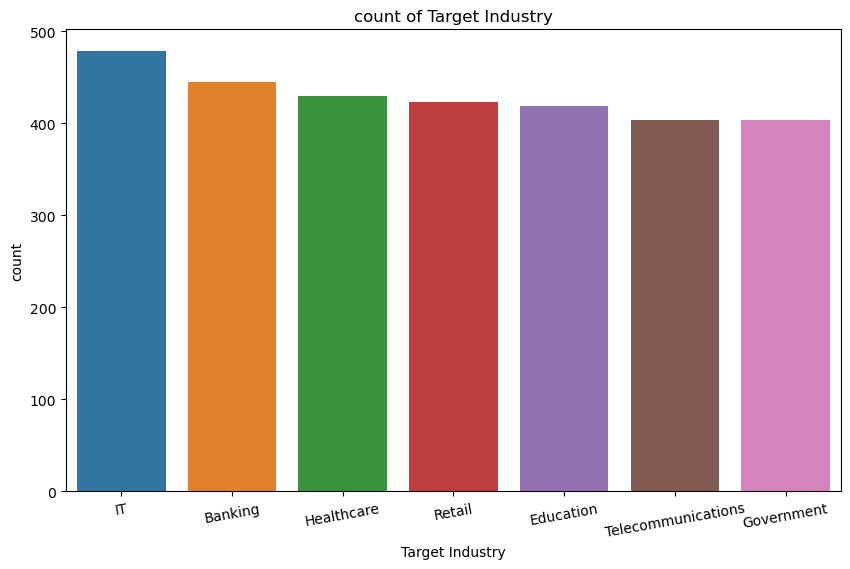

In [22]:
# Visualizing the count of Target Industry
plt.figure(figsize=(10,6))
sns.countplot(df_Global_Cybersecurity_Threats_2015_2024_Dataset['Target Industry'],order=df_Global_Cybersecurity_Threats_2015_2024_Dataset['Target Industry'].value_counts().index)
plt.title('count of Target Industry')
print(df_Global_Cybersecurity_Threats_2015_2024_Dataset['Target Industry'].value_counts())
plt.xticks(rotation=10)

The distribution of **Target Industry** is relatively balanced, although some sectors record slightly more incidents than others. The **IT** industry has the highest number of cases with **478 incidents**, followed by **Banking** with **445** and **Healthcare** with **429**. **Retail** accounts for **423 cases**, while **Education** records **419**. The lowest counts are observed in **Telecommunications** and **Government**, each with **403 incidents**. However, the slightly higher counts in **IT**, **Banking**, and **Healthcare** indicates that these industries are more frequently targeted or more exposed to cyber risk.

Nation-state    794
Unknown         768
Insider         752
Hacker Group    686
Name: Attack Source, dtype: int64


(array([0, 1, 2, 3]),
 [Text(0, 0, 'Nation-state'),
  Text(1, 0, 'Unknown'),
  Text(2, 0, 'Insider'),
  Text(3, 0, 'Hacker Group')])

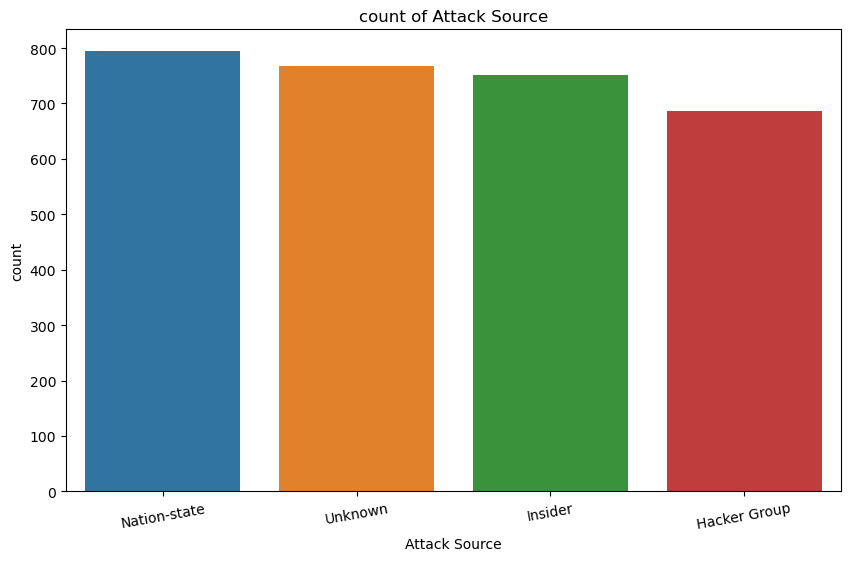

In [23]:
# Visualizing the count of Attack Source
plt.figure(figsize=(10,6))
sns.countplot(df_Global_Cybersecurity_Threats_2015_2024_Dataset['Attack Source'],order=df_Global_Cybersecurity_Threats_2015_2024_Dataset['Attack Source'].value_counts().index)
plt.title('count of Attack Source')
print(df_Global_Cybersecurity_Threats_2015_2024_Dataset['Attack Source'].value_counts())
plt.xticks(rotation=10)

The above distribution of **Attack Source** is relatively balanced.**Nation-state** accounts for the highest number of incidents with **794 cases**, followed by **Unknown** with **768** and **Insider** with **752**. **Hacker Group** records the lowest count at **686 cases**.

Zero-day              785
Social Engineering    747
Unpatched Software    738
Weak Passwords        730
Name: Security Vulnerability Type, dtype: int64


(array([0, 1, 2, 3]),
 [Text(0, 0, 'Zero-day'),
  Text(1, 0, 'Social Engineering'),
  Text(2, 0, 'Unpatched Software'),
  Text(3, 0, 'Weak Passwords')])

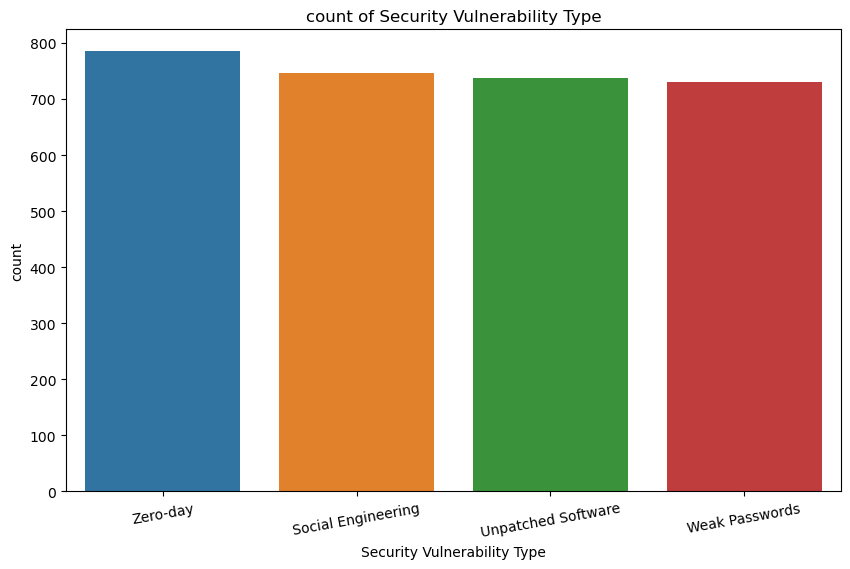

In [24]:
# Visualizing the count of Security Vulnerability Type
plt.figure(figsize=(10,6))
sns.countplot(df_Global_Cybersecurity_Threats_2015_2024_Dataset['Security Vulnerability Type'],order=df_Global_Cybersecurity_Threats_2015_2024_Dataset['Security Vulnerability Type'].value_counts().index)
plt.title('count of Security Vulnerability Type')
print(df_Global_Cybersecurity_Threats_2015_2024_Dataset['Security Vulnerability Type'].value_counts())
plt.xticks(rotation=10)

The distribution of **Security Vulnerability Type** is fairly balanced across the dataset, with only modest differences between categories. **Zero-day** vulnerabilities are the most frequent with **785 cases**, followed by **Social Engineering** with **747**, **Unpatched Software** with **738**, and **Weak Passwords** with **730**. The slightly higher count for **Zero-day** indicates that newly exploited vulnerabilities play a more prominent role in the recorded incidents.

Antivirus             628
VPN                   612
Encryption            592
Firewall              585
AI-based Detection    583
Name: Defense Mechanism Used, dtype: int64


(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Antivirus'),
  Text(1, 0, 'VPN'),
  Text(2, 0, 'Encryption'),
  Text(3, 0, 'Firewall'),
  Text(4, 0, 'AI-based Detection')])

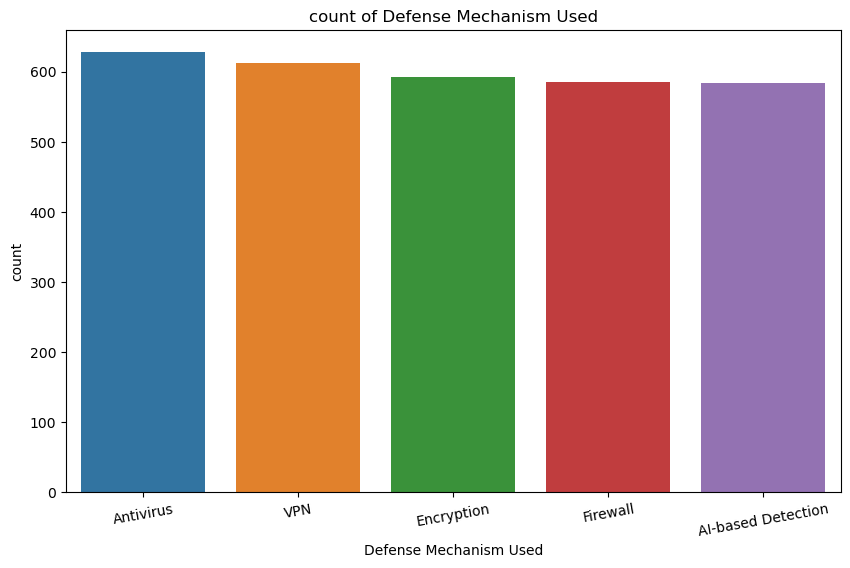

In [25]:
# Visualizing the count of Defense Mechanism Used
plt.figure(figsize=(10,6))
sns.countplot(df_Global_Cybersecurity_Threats_2015_2024_Dataset['Defense Mechanism Used'],order=df_Global_Cybersecurity_Threats_2015_2024_Dataset['Defense Mechanism Used'].value_counts().index)
plt.title('count of Defense Mechanism Used')
print(df_Global_Cybersecurity_Threats_2015_2024_Dataset['Defense Mechanism Used'].value_counts())
plt.xticks(rotation=10)

As shown in the above distribution of Defense Mechanism Used, the **Antivirus** is the most frequently used defense mechanism with 628 cases, followed by **VPN** with 612, **Encryption** with 592, **Firewall** with 585, and **AI-based Detection** with 583.

**Checking The Skewness**

In [26]:
# Lets have a look at the skewness
df_Global_Cybersecurity_Threats_2015_2024_Dataset.skew()

Year                                  -0.027513
Financial Loss (in Million $)         -0.016860
Number of Affected Users              -0.025397
Incident Resolution Time (in Hours)    0.011104
dtype: float64

**Removing The Skewness**

In [27]:
# Removing skewness using the cuberoot method
df_Global_Cybersecurity_Threats_2015_2024_Dataset['Year'] = np .cbrt(df_Global_Cybersecurity_Threats_2015_2024_Dataset['Year'])
df_Global_Cybersecurity_Threats_2015_2024_Dataset['Financial Loss (in Million $)'] = np .cbrt(df_Global_Cybersecurity_Threats_2015_2024_Dataset['Financial Loss (in Million $)'])
df_Global_Cybersecurity_Threats_2015_2024_Dataset['Number of Affected Users'] = np .cbrt(df_Global_Cybersecurity_Threats_2015_2024_Dataset['Number of Affected Users'])

In [28]:
# Let us Check the skewness once again
df_Global_Cybersecurity_Threats_2015_2024_Dataset.skew()

Year                                  -0.028602
Financial Loss (in Million $)         -0.801528
Number of Affected Users              -0.897946
Incident Resolution Time (in Hours)    0.011104
dtype: float64

**Visualizing the data distribution in the columns after checking skewness.**

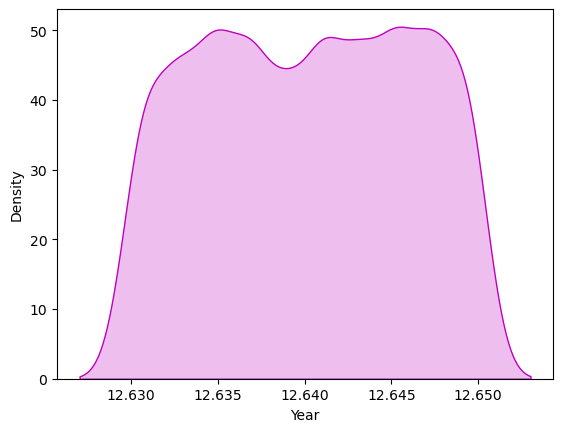

In [29]:
# Data distribution in Year after skewness
sns.distplot(df_Global_Cybersecurity_Threats_2015_2024_Dataset['Year'], color = "m", kde_kws = {"shade":True}, hist = False)
plt.show()

The Yearly distribution appears relatively uniform across the dataset, with no sharp peaks or major declines concentrated in a specific period. The density remains fairly stable throughout the observed range, which means that cybersecurity incidents were consistently recorded over time rather than being clustered in only a few years.

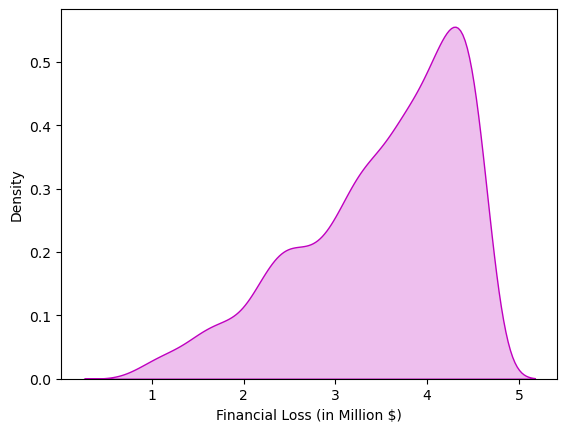

In [30]:
# Data distribution in Financial Loss(in Million $)after skewness
sns.distplot(df_Global_Cybersecurity_Threats_2015_2024_Dataset['Financial Loss (in Million $)'], color = "m", kde_kws = {"shade":True}, hist = False)
plt.show()

The distribution of **Financial Loss (in Million $)** is skewed toward the higher end, with most incidents concentrated between roughly **3 million and 4.5 million dollars**. The Lower loss values appear less frequently, while the density peaks around the upper range of the distribution an indication that a large number of recorded cybersecurity incidents are associated with relatively substantial financial impact.

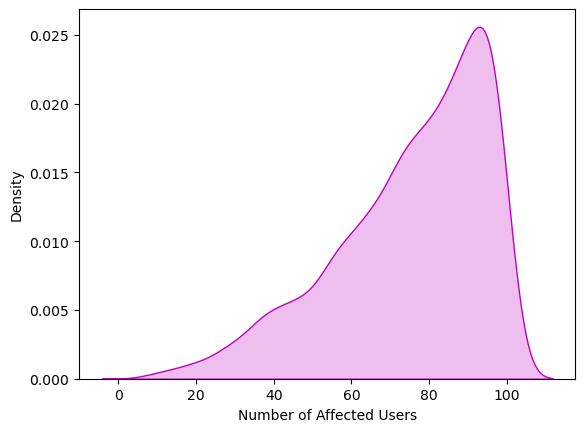

In [31]:
# Data distribution in Number of Affected Users after skewness
sns.distplot(df_Global_Cybersecurity_Threats_2015_2024_Dataset['Number of Affected Users'], color = "m", kde_kws = {"shade":True}, hist = False)
plt.show()

The distribution of **Number of Affected Users** is concentrated toward the higher end, with most incidents affecting roughly **60 to 100 users**. Lower user counts appear less frequently, while the highest density is observed close to the upper range. 

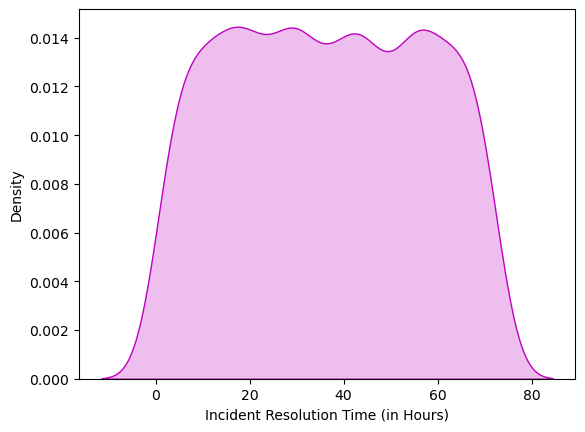

In [32]:
# Data distribution in Incident Resolution Time (in Hours) after skewness
sns.distplot(df_Global_Cybersecurity_Threats_2015_2024_Dataset['Incident Resolution Time (in Hours)'], color = "m", kde_kws = {"shade":True}, hist = False)
plt.show()

The distribution of **Incident Resolution Time (in Hours)** appears fairly even across the dataset, with values spread broadly through the observed range and no sharp concentration in a single interval. This suggests that incident response times vary considerably, indicating a combination of cybersecurity incidents that are quickly resolved and those that took longer time to be resolved.


**Bivariate analysis**

Checking the relationships between the target and feature variables

<AxesSubplot:title={'center':'Financial Loss (in Million $) in relation with Target(Attack Type)'}, xlabel='Financial Loss (in Million $)', ylabel='Attack Type'>

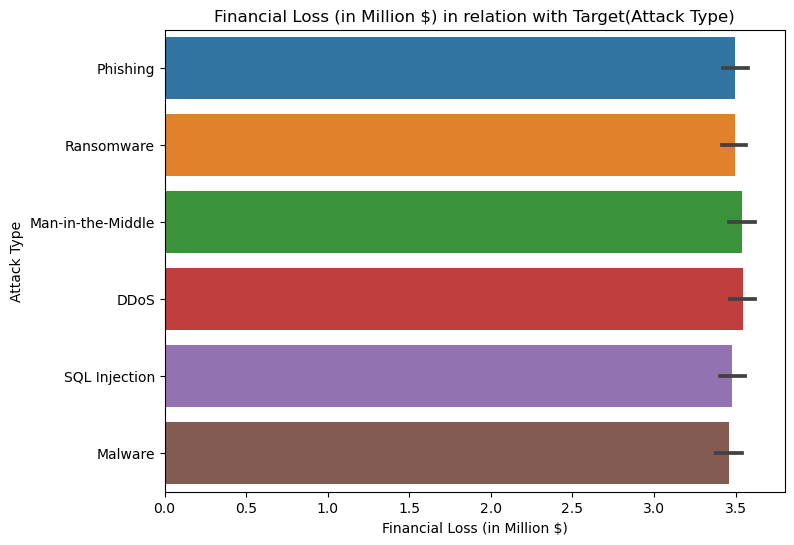

In [33]:
# barplot for Financial Loss (in Million $) in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("Financial Loss (in Million $) in relation with Target(Attack Type)")
sns.barplot(x = 'Financial Loss (in Million $)', y = 'Attack Type', data = df_Global_Cybersecurity_Threats_2015_2024_Dataset)

This chart shows that average financial loss is fairly similar across all attack types, with values clustered around **3.5 million dollars**. **Phishing, Man-in-the-Middle, and DDoS** appear to record slightly higher losses, while **Malware, SQL Injection, and Ransomware** are marginally lower.

<AxesSubplot:title={'center':'Number of Affected Users in relation with Target(Attack Type)'}, xlabel='Number of Affected Users', ylabel='Attack Type'>

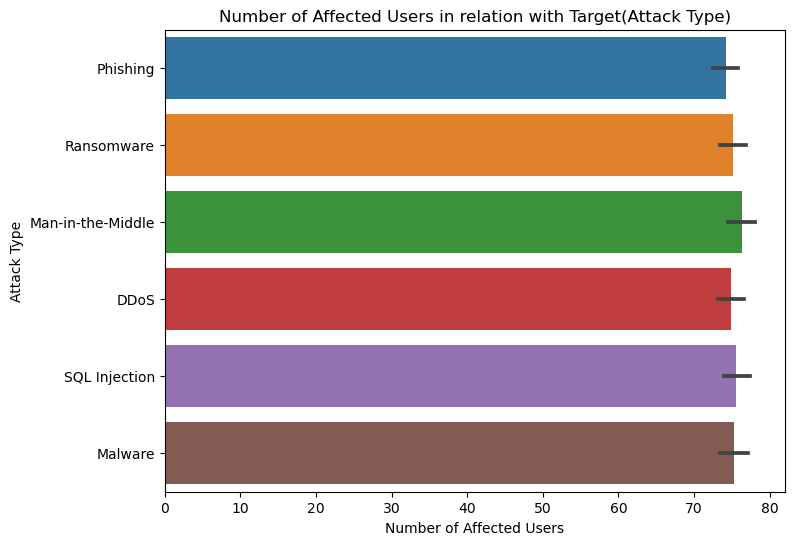

In [34]:
# barplot for Number of Affected Users in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("Number of Affected Users in relation with Target(Attack Type)")
sns.barplot(x = 'Number of Affected Users', y = 'Attack Type', data = df_Global_Cybersecurity_Threats_2015_2024_Dataset)

The above chart indicates that the **average number of affected users** is also quite similar across the different **attack types**, with values mostly clustered between **74 and 77 users**. **Man-in-the-Middle** appears to affect the highest average number of users, while **Phishing** shows the lowest, though this gaps are very small.


<AxesSubplot:title={'center':'Incident Resolution Time (in Hours) in relation with Target(Attack Type)'}, xlabel='Incident Resolution Time (in Hours)', ylabel='Attack Type'>

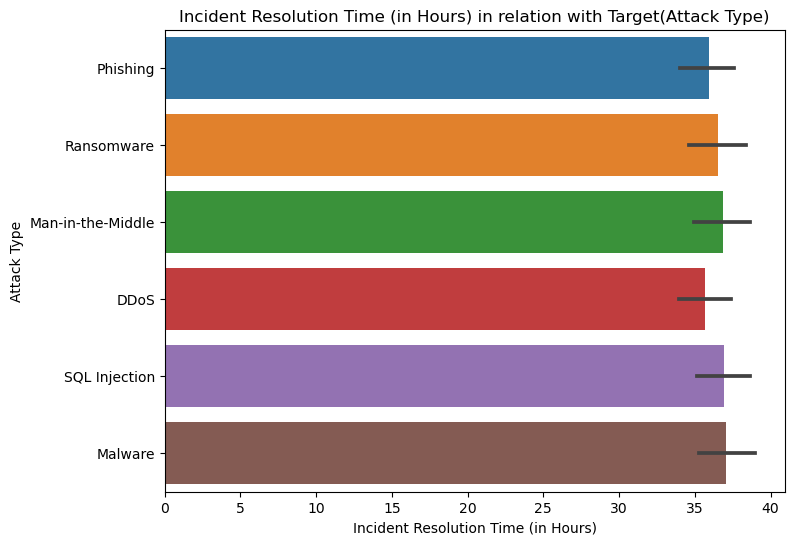

In [35]:
# barplot for Incident Resolution Time (in Hours) in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("Incident Resolution Time (in Hours) in relation with Target(Attack Type)")
sns.barplot(x = 'Incident Resolution Time (in Hours)', y = 'Attack Type', data = df_Global_Cybersecurity_Threats_2015_2024_Dataset)

This chart shows that **incident resolution time** is fairly similar across all **attack types**, with average values mostly ranging from about **36 to 37 hours**. **Malware** and **SQL Injection** appear to take slightly longer time to resolve, while **DDoS** and **Phishing** are resolved a little faster.Hence,the response time is widely consistent across the various attack categories in the dataset.


### Correlation Analysis

**Correlation between Target variable and Independent Variables.**

In [36]:
# Checking the correlation between features and the target.
cor = df_Global_Cybersecurity_Threats_2015_2024_Dataset.corr()
cor

,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
Year,1.000000,0.011733,0.010414,-0.004989
Financial Loss (in Million $),0.011733,1.000000,-0.003154,-0.015196
Number of Affected Users,0.010414,-0.003154,1.000000,0.004787
Incident Resolution Time (in Hours),-0.004989,-0.015196,0.004787,1.000000


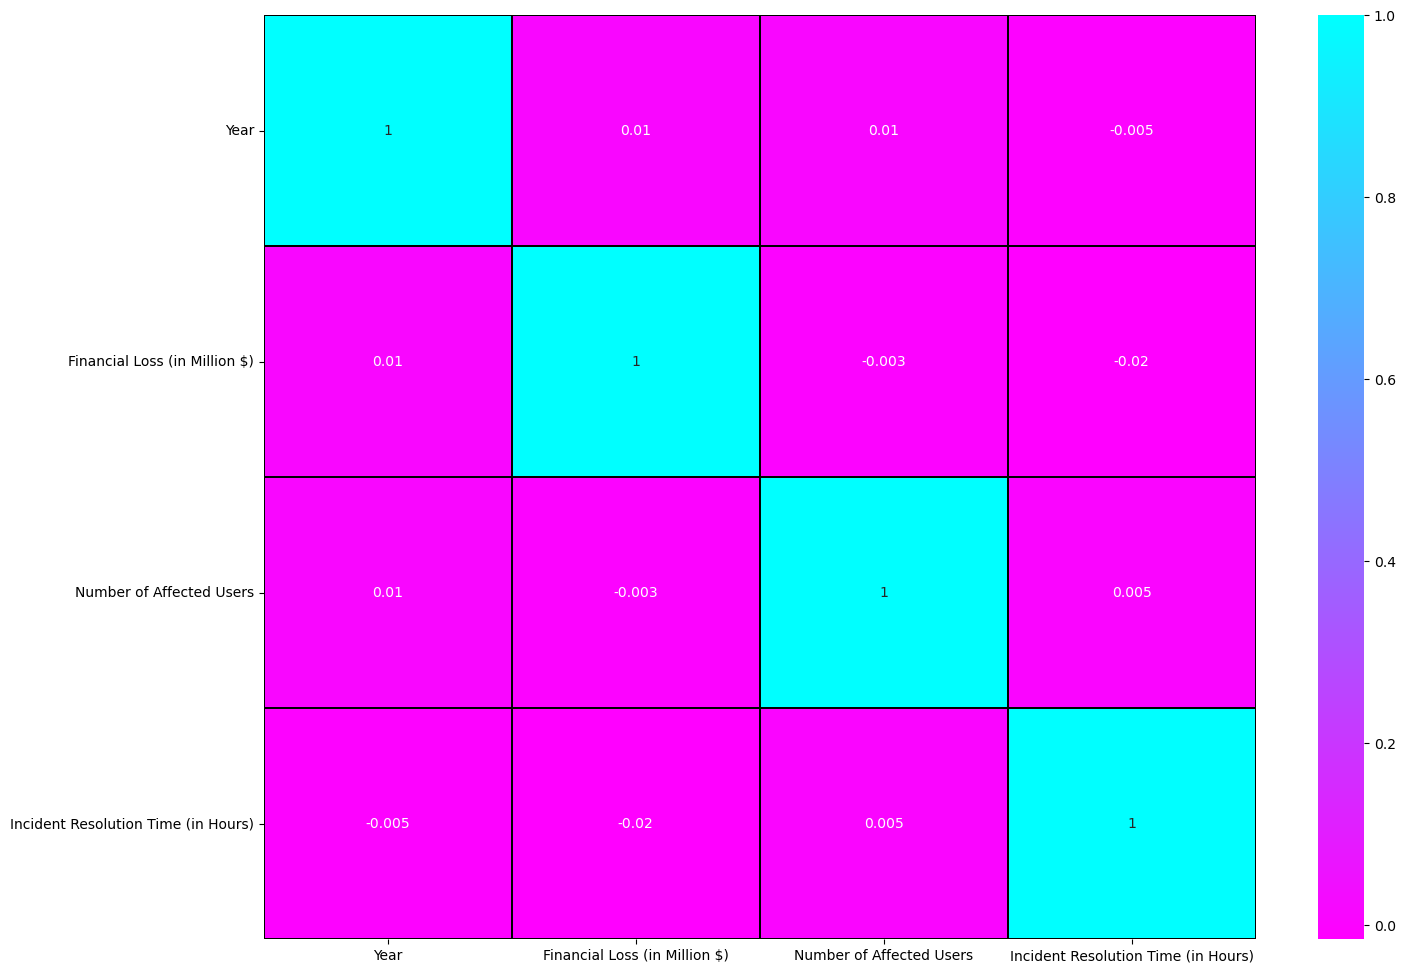

In [37]:
# Visualizing the correlation matrix by plotting heatmap
plt.figure(figsize = (16, 12))
sns.heatmap(df_Global_Cybersecurity_Threats_2015_2024_Dataset.corr(), linewidths = 0.1, fmt = ".1g", linecolor = "black", annot = True, cmap = "cool_r")
plt.yticks(rotation = 0);
plt.show()

In [38]:
# Computing the correlation of all numeric columns with Target
df_Global_Cybersecurity_Threats_2015_2024_Dataset.corr()['Year'].sort_values(ascending = False)

Year                                   1.000000
Financial Loss (in Million $)          0.011733
Number of Affected Users               0.010414
Incident Resolution Time (in Hours)   -0.004989
Name: Year, dtype: float64

All the features have the strongest positive relationship with the "Year" except for "Incident Resolution Time (in Hours)"  which has a -ve correlation.

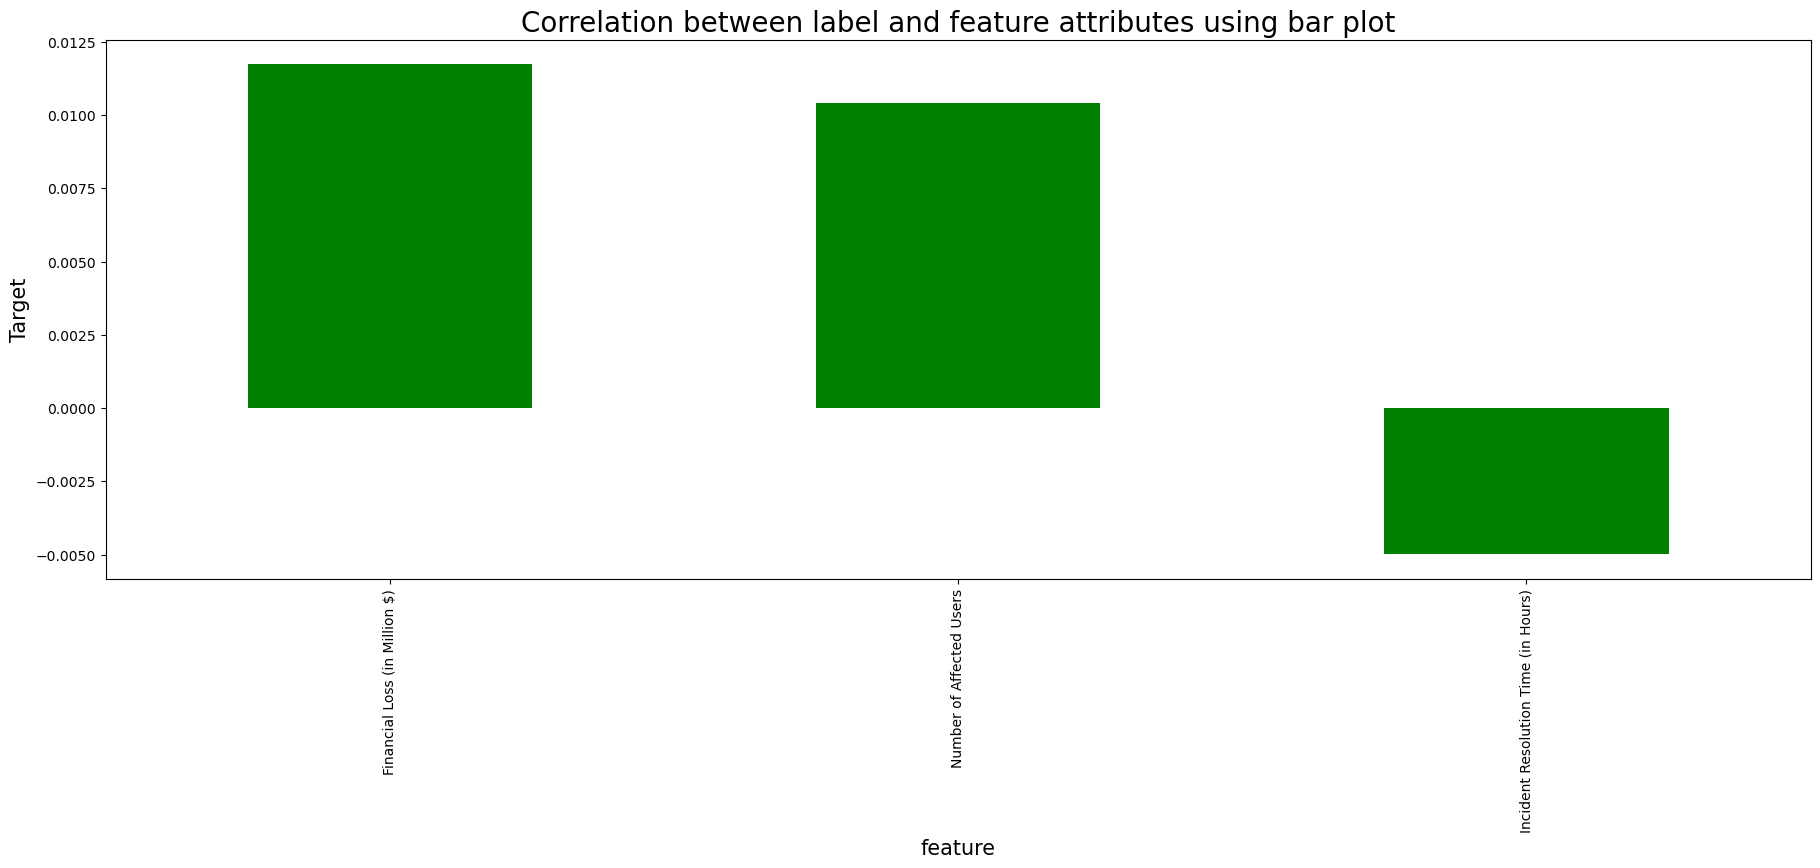

In [39]:
plt.figure(figsize = (22, 7))
df_Global_Cybersecurity_Threats_2015_2024_Dataset.corr()['Year'].sort_values(ascending = False).drop(['Year']).plot(kind='bar',color="g")
plt.xlabel('feature', fontsize = 15)
plt.ylabel('Target', fontsize = 15)
plt.title("Correlation between label and feature attributes using bar plot", fontsize=20)
plt.show()

The bar plot shows that the **Financial Loss (in Million $)** has the highest positive relationship with the target, followed closely by **Number of Affected Users**, while **Incident Resolution Time (in Hours)** shows a slight negative relationship. 


### Feature Engineering & Preprocessing

**Identifying our independent variable (x) and dependant/target variable (y)**

In [40]:
x = df_Global_Cybersecurity_Threats_2015_2024_Dataset.drop("Country", axis =1)
y = df_Global_Cybersecurity_Threats_2015_2024_Dataset["Year"]

#### Feature Scaling using standard scalarization

In [41]:
# Encode categorical columns
x_encoded = x.copy()
for col in x_encoded.select_dtypes(include=['object']).columns:
    x_encoded[col] = LabelEncoder().fit_transform(x_encoded[col])

In [42]:
# Scale the encoded data
scaler = StandardScaler()
x_scaled = pd.DataFrame(scaler.fit_transform(x_encoded), columns=x_encoded.columns)

x_scaled.head()

,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,-0.199139,0.294581,-0.997819,0.930373,0.849362,-1.403203,-0.45917,1.411510,1.289617
1,-0.199139,0.874846,1.012224,0.524238,-0.439390,-1.403203,-0.45917,0.703986,1.678584
2,-0.899416,-0.285684,0.509713,-0.137656,0.482147,-1.403203,0.42783,1.411510,-0.801076
3,1.549532,0.874846,1.514735,-0.047102,0.606066,0.409721,-1.34617,-1.418586,-1.433146
4,-0.549220,-0.285684,0.509713,0.802427,0.924256,-0.496741,-1.34617,1.411510,1.532721


In [43]:
x_scaled.tail()

,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
2995,0.500675,0.874846,-0.495308,0.246957,-0.904981,1.316182,-1.34617,0.703986,0.754789
2996,1.200028,1.455110,1.514735,-0.438658,1.080563,-1.403203,1.31483,1.411510,-0.509351
2997,-0.899416,1.455110,0.509713,-0.336459,0.770078,0.409721,0.42783,-1.418586,-0.314868
2998,0.850409,1.455110,0.509713,-0.366253,-0.142731,-0.496741,-0.45917,0.703986,-1.335904
2999,0.500675,1.455110,1.012224,0.156599,0.160850,1.316182,1.31483,1.411510,1.338238


#### Checking Variance Inflation Factor(VIF)

In [44]:
# Start with a copy
X = x.copy()   # your feature DataFrame

In [45]:
# Inspect dtypes and non-numeric columns
print("Column dtypes:\n", X.dtypes)
non_numeric = X.select_dtypes(include=['object', 'category']).columns.tolist()
print("Non-numeric columns:", non_numeric)

Column dtypes:
 Year                                   float64
Attack Type                             object
Target Industry                         object
Financial Loss (in Million $)          float64
Number of Affected Users               float64
Attack Source                           object
Security Vulnerability Type             object
Defense Mechanism Used                  object
Incident Resolution Time (in Hours)      int64
dtype: object
Non-numeric columns: ['Attack Type', 'Target Industry', 'Attack Source', 'Security Vulnerability Type', 'Defense Mechanism Used']


In [46]:
# If there are categorical cols, decide strategy:
#    - For VIF it's common to compute on numeric features only,
#    - or encode low-cardinality categoricals with get_dummies (watch cardinality).
low_card = [c for c in non_numeric if X[c].nunique() <= 10]   # threshold adjust as needed
high_card = [c for c in non_numeric if X[c].nunique() > 10]
print("Low-cardinality categoricals:", low_card)
print("High-cardinality categoricals (consider dropping/encoding differently):", high_card)

Low-cardinality categoricals: ['Attack Type', 'Target Industry', 'Attack Source', 'Security Vulnerability Type', 'Defense Mechanism Used']
High-cardinality categoricals (consider dropping/encoding differently): []


In [47]:
# Lets drop high-cardinality categoricals and one-hot encode low-cardinality
X = X.drop(columns=high_card)   # drop or handle differently
if low_card:
    X = pd.get_dummies(X, columns=low_card, drop_first=True)

In [48]:
# Drop constant columns (zero variance)
nunique = X.nunique()
const_cols = nunique[nunique <= 1].index.tolist()
if const_cols:
    print("Dropping constant columns:", const_cols)
    X = X.drop(columns=const_cols)

In [49]:
# Handle missing values: either drop or impute
# Option: impute with median (safer than dropping if many rows)
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [50]:
# lets Ensure numeric dtype and finite values
X_imputed = X_imputed.astype(float)
if not np.isfinite(X_imputed.values).all():
    raise ValueError("Non-finite values detected after imputation/convert. Check data.")

In [51]:
# lets now Compute VIF
vif_df_Global_Cybersecurity_Threats_2015_2024_Dataset = pd.DataFrame()
vif_df_Global_Cybersecurity_Threats_2015_2024_Dataset['feature'] = X_imputed.columns
vif_df_Global_Cybersecurity_Threats_2015_2024_Dataset['VIF'] = [variance_inflation_factor(X_imputed.values, i) for i in range(X_imputed.shape[1])]
vif_df_Global_Cybersecurity_Threats_2015_2024_Dataset = vif_df_Global_Cybersecurity_Threats_2015_2024_Dataset.sort_values('VIF', ascending=False).reset_index(drop=True)
print(vif_df_Global_Cybersecurity_Threats_2015_2024_Dataset)

                                           feature        VIF
0                                             Year  56.986963
1                    Financial Loss (in Million $)  17.042289
2                         Number of Affected Users  15.929497
3              Incident Resolution Time (in Hours)   4.164358
4                       Attack Source_Nation-state   2.172483
5                            Attack Source_Unknown   2.131316
6                            Attack Source_Insider   2.115565
7                 Defense Mechanism Used_Antivirus   2.090736
8                               Target Industry_IT   2.090293
9             Security Vulnerability Type_Zero-day   2.066476
10                      Defense Mechanism Used_VPN   2.055208
11               Defense Mechanism Used_Encryption   2.030551
12                            Attack Type_Phishing   2.019998
13                 Defense Mechanism Used_Firewall   2.015145
14  Security Vulnerability Type_Unpatched Software   1.999317
15      

### Handling imbalanced target variable Using SMOTE

In [52]:
y.value_counts()

12.634808    319
12.645239    318
12.647324    315
12.641069    315
12.636895    310
12.649407    299
12.643154    299
12.632719    285
12.630630    277
12.638982    263
Name: Year, dtype: int64

#### Oversampling using SMOTE

In [53]:
print(x.shape, y.shape)

(3000, 9) (3000,)


In [54]:
print(x.dtypes)

Year                                   float64
Attack Type                             object
Target Industry                         object
Financial Loss (in Million $)          float64
Number of Affected Users               float64
Attack Source                           object
Security Vulnerability Type             object
Defense Mechanism Used                  object
Incident Resolution Time (in Hours)      int64
dtype: object


In [55]:
print(x.shape)

(3000, 9)


In [56]:
print(pd.Series(y).dtype, pd.Series(y).value_counts())

float64 12.634808    319
12.645239    318
12.647324    315
12.641069    315
12.636895    310
12.649407    299
12.643154    299
12.632719    285
12.630630    277
12.638982    263
Name: Year, dtype: int64


In [57]:
# ASSUMES: your DataFrame is `x` and target is `y` as provided
X = x.copy()
y_ser = pd.Series(y)

In [58]:
# Basic checks
print("Initial shape X:", X.shape)
print("Initial class distribution:\n", y_ser.value_counts())

Initial shape X: (3000, 9)
Initial class distribution:
 12.634808    319
12.645239    318
12.647324    315
12.641069    315
12.636895    310
12.649407    299
12.643154    299
12.632719    285
12.630630    277
12.638982    263
Name: Year, dtype: int64


In [59]:
# Drop obvious identifiers / long text which are not useful for SMOTE
to_drop = [
      # drop IDs if we are not using them as features
]
existing_to_drop = [c for c in to_drop if c in X.columns]
if existing_to_drop:
    print("Dropping columns:", existing_to_drop)
    X = X.drop(columns=existing_to_drop)

In [60]:
y = y.round().astype(int)

In [61]:
X = df_Global_Cybersecurity_Threats_2015_2024_Dataset.drop('Attack Type', axis=1)
y = df_Global_Cybersecurity_Threats_2015_2024_Dataset['Attack Type']

In [62]:
X = pd.get_dummies(X)

In [63]:
sm = SMOTE(random_state=42)
x_res, y_res = sm.fit_resample(X, y)

In [64]:
# checking the value count of target column
y.value_counts()

DDoS                 531
Phishing             529
SQL Injection        503
Ransomware           493
Malware              485
Man-in-the-Middle    459
Name: Attack Type, dtype: int64

### Train-Test Split

**SPLITTING THE DATA INTO TRAIN AND TEST USING THE 70:30 RULE**

In [65]:
x_train, x_test, y_train, y_test = train_test_split(x_res,y_res,test_size=0.3,random_state=42,
                                                    shuffle=True,stratify=y_res)

### Setting The Base Accuracy Score

**Locating the best random state**

In [66]:
# Base accuracy score should be better than always predicting the High-risk

# Baseline accuracy = proportion of the Attack Type 
counts = df_Global_Cybersecurity_Threats_2015_2024_Dataset['Attack Type'].value_counts()
baseline_acc = counts.max() / counts.sum() * 100
print(f"Baseline accuracy to beat: {baseline_acc:.2f}%")

Baseline accuracy to beat: 17.70%


### Machine Learning Models

### Logistic Regression

In [67]:
# Checking accuracy for Logistic Regression
logr = LogisticRegression()

In [68]:
logr.fit(x_train, y_train)

LogisticRegression()

Classification Report (LR):
                    precision    recall  f1-score   support

             DDoS       0.20      0.24      0.22       159
          Malware       0.22      0.13      0.16       159
Man-in-the-Middle       0.22      0.25      0.23       159
         Phishing       0.22      0.21      0.21       160
       Ransomware       0.21      0.19      0.20       160
    SQL Injection       0.16      0.19      0.18       159

         accuracy                           0.20       956
        macro avg       0.20      0.20      0.20       956
     weighted avg       0.20      0.20      0.20       956

Confusion Matrix (LR):
 [[38 18 21 27 24 31]
 [38 20 33 16 23 29]
 [33 12 40 19 26 29]
 [25 12 26 33 20 44]
 [27 17 32 30 30 24]
 [33 14 33 26 22 31]]


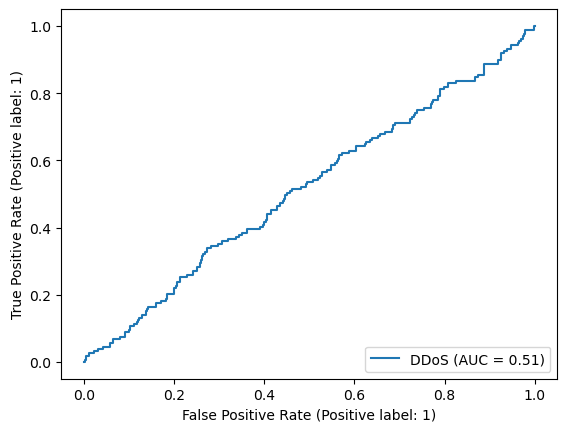

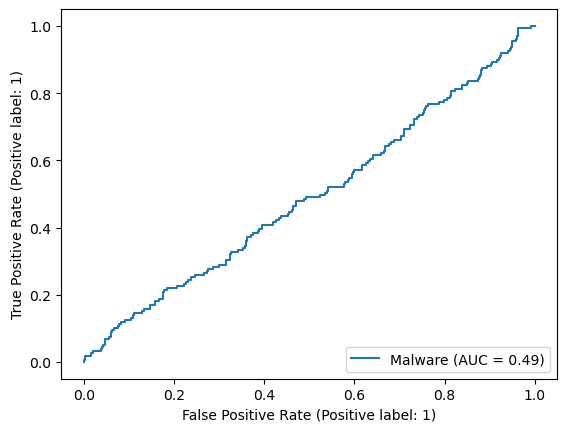

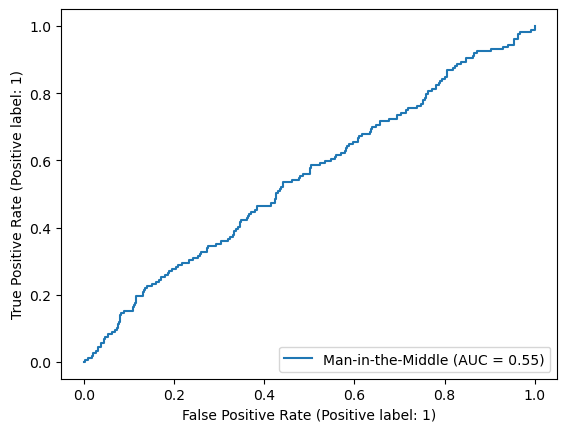

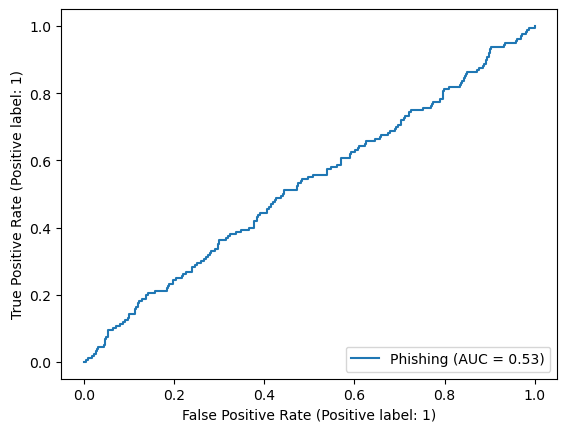

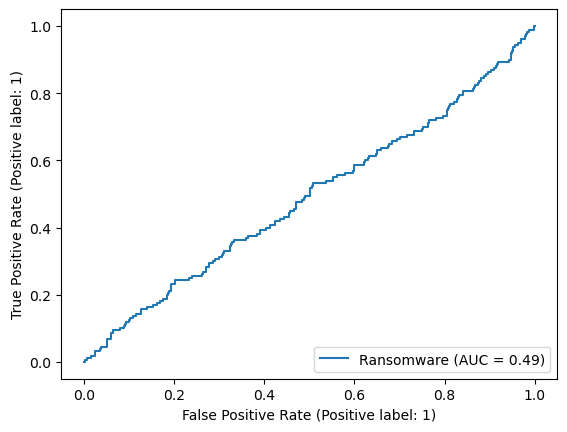

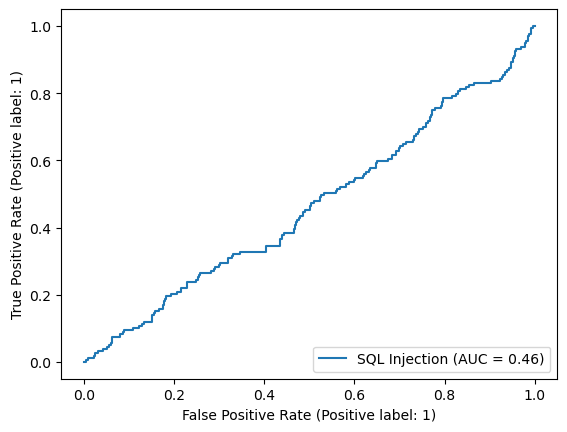

In [69]:
# y_test, x_test, lor must exist (logr is our trained LogisticRegression)

print("Classification Report (LR):\n", classification_report(y_test, logr.predict(x_test)))
print("Confusion Matrix (LR):\n", confusion_matrix(y_test, logr.predict(x_test)))

y_test_bin = label_binarize(y_test, classes=logr.classes_)

for i, class_name in enumerate(logr.classes_):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i],
        logr.predict_proba(x_test)[:, i],
        name=f"{class_name}"
    )

plt.show()

The logistic regression model achieved an **accuracy of 20%**, compared with the baseline accuracy of **17.70%**. This means the model outperformed the baseline by only **2.30%**, indicating a very little improvement. Although the result is slightly better than the baseline.This was further supported by the ROC curves, where AUC values ranged from **46% to 55%**.

### Random Forest Classifier

In [70]:
Rfor = RandomForestClassifier()

In [71]:
Rfor.fit(x_train, y_train)

RandomForestClassifier()

Classification Report (RF):
                    precision    recall  f1-score   support

             DDoS       0.12      0.13      0.13       159
          Malware       0.22      0.19      0.21       159
Man-in-the-Middle       0.22      0.24      0.23       159
         Phishing       0.16      0.16      0.16       160
       Ransomware       0.16      0.14      0.15       160
    SQL Injection       0.17      0.18      0.17       159

         accuracy                           0.17       956
        macro avg       0.17      0.17      0.17       956
     weighted avg       0.17      0.17      0.17       956

Confusion Matrix (RF):
 [[21 32 28 23 29 26]
 [24 31 21 27 26 30]
 [28 16 38 25 25 27]
 [34 20 25 25 25 31]
 [37 19 30 27 23 24]
 [31 23 31 26 20 28]]


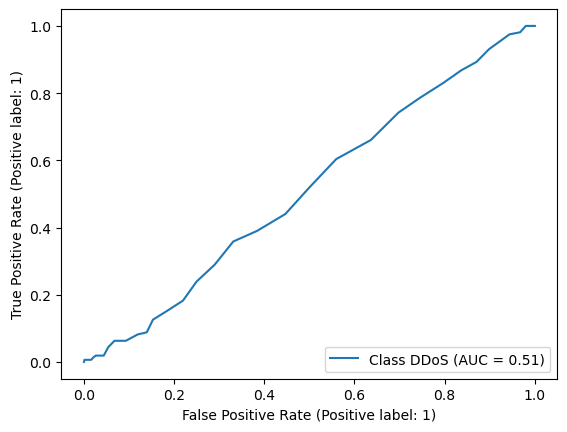

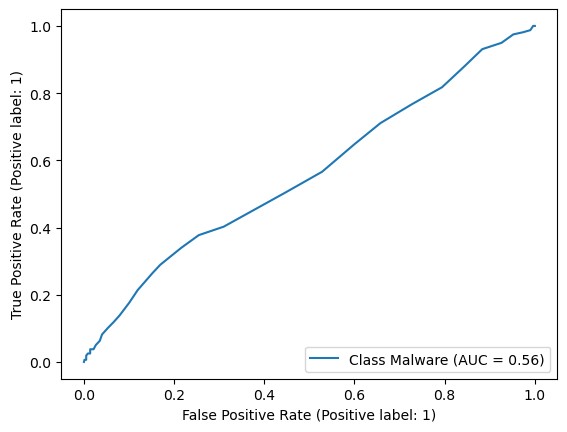

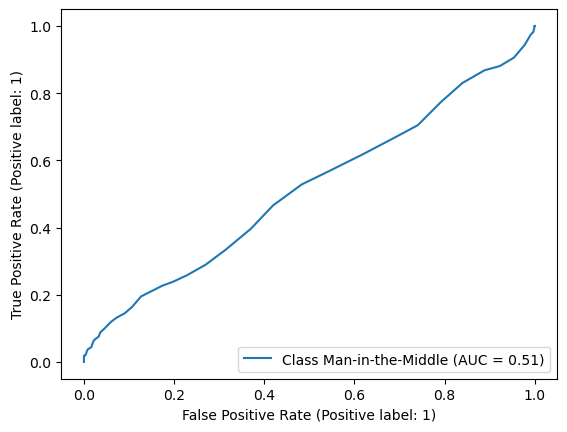

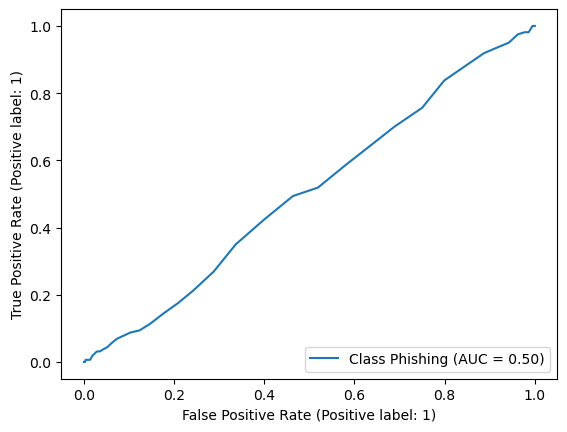

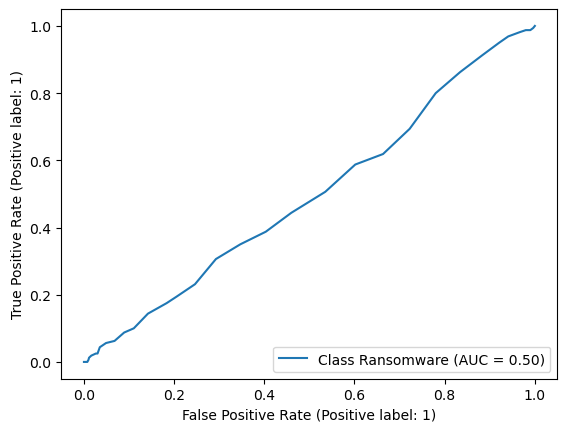

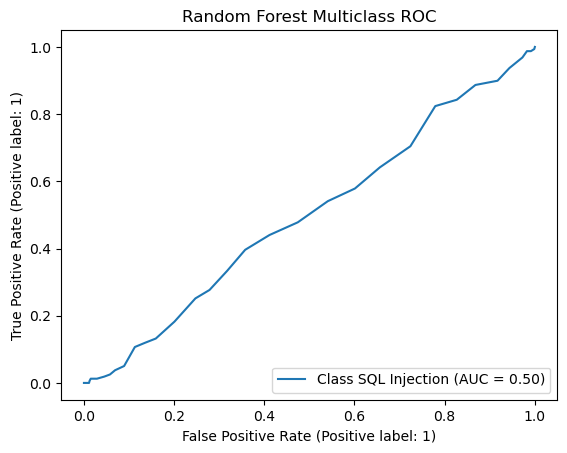

In [72]:
# y_test, x_test,while Rfor exists has our trained Random Forest Classifier
print("Classification Report (RF):\n", classification_report(y_test, Rfor.predict(x_test)))
print("Confusion Matrix (RF):\n", confusion_matrix(y_test, Rfor.predict(x_test)))

# convert y_test to binary format
y_test_bin = label_binarize(y_test, classes=Rfor.classes_)

# get predicted probabilities
y_score = Rfor.predict_proba(x_test)

# plot ROC for each class
for i, class_name in enumerate(Rfor.classes_):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i],
        y_score[:, i],
        name=f"Class {class_name}"
    )

plt.title("Random Forest Multiclass ROC")
plt.show()

The Random Forest model achieved **18% accuracy**, only slightly above the **17.70% baseline**, which indicates very limited improvement.Among the classes, **Man-in-the-Middle** performed best with an F1-score of **0.27** and the highest AUC of **0.56**, while **SQL Injection** had the weakest ROC result with an AUC of **0.47** while most other class AUC values were around **0.52**.Hence,the Random Forest model performed only marginally better than baseline.

### k-Nearest Neighbors (KNN)

In [73]:
# Creating a KNN Classifier
clasf_knn = KNeighborsClassifier(n_neighbors=5)

In [74]:
clasf_knn.fit(x_train, y_train)

KNeighborsClassifier()

Classification Report (KNN):
                    precision    recall  f1-score   support

             DDoS       0.19      0.25      0.22       159
          Malware       0.22      0.25      0.23       159
Man-in-the-Middle       0.22      0.26      0.24       159
         Phishing       0.13      0.10      0.11       160
       Ransomware       0.20      0.16      0.18       160
    SQL Injection       0.18      0.14      0.16       159

         accuracy                           0.19       956
        macro avg       0.19      0.19      0.19       956
     weighted avg       0.19      0.19      0.19       956

Confusion Matrix (KNN):
 [[40 28 24 14 28 25]
 [31 40 29 23 16 20]
 [23 30 42 24 23 17]
 [40 25 42 16 19 18]
 [36 29 28 23 26 18]
 [38 31 26 23 19 22]]


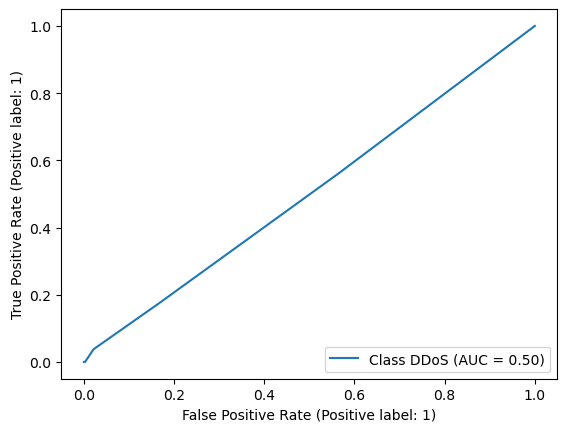

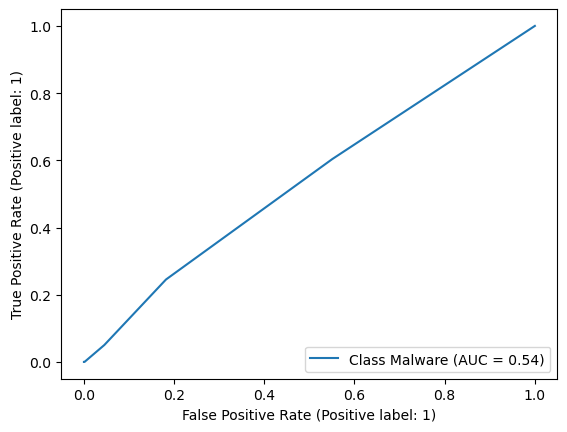

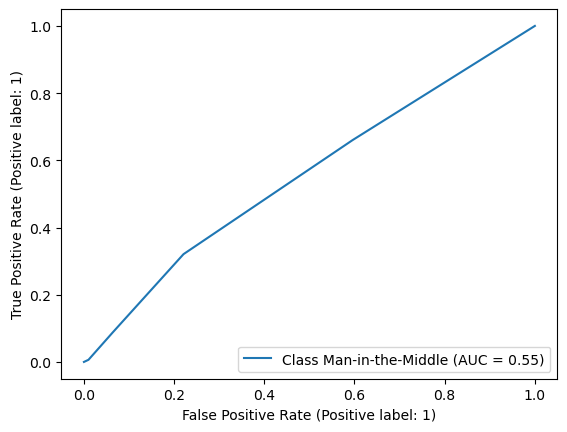

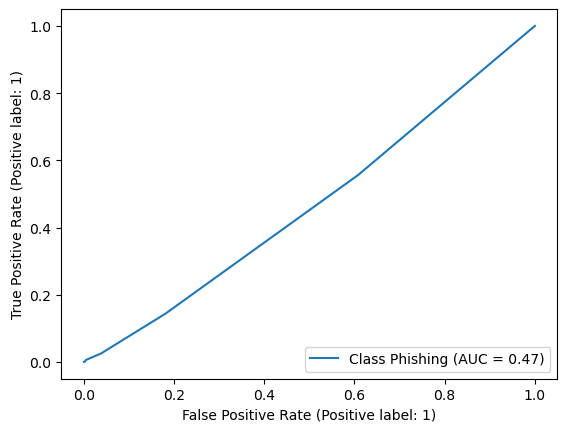

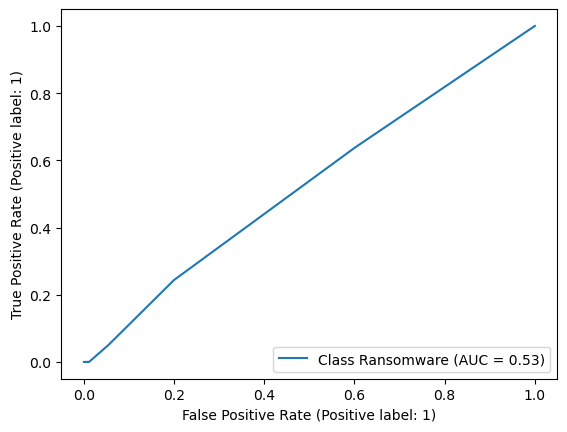

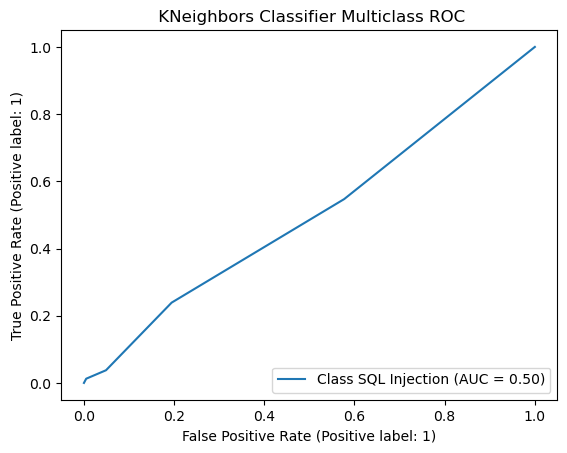

In [75]:
# y_test, x_test,while KNN exists has our trained KNN Classifier
print("Classification Report (KNN):\n", classification_report(y_test, clasf_knn.predict(x_test)))
print("Confusion Matrix (KNN):\n", confusion_matrix(y_test, clasf_knn.predict(x_test)))

# convert y_test to binary format
y_test_bin = label_binarize(y_test, classes=clasf_knn.classes_)

# get predicted probabilities
y_score = clasf_knn.predict_proba(x_test)

# plot ROC for each class
for i, class_name in enumerate(clasf_knn.classes_):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i],
        y_score[:, i],
        name=f"Class {class_name}"
    )

plt.title(" KNeighbors Classifier Multiclass ROC")
plt.show()

The KNN model achieved **19% accuracy**, slightly above the **17.70% baseline**, indicating only a small improvement over chance-level performance. Its overall precision, recall, and F1-scores were low, with macro and weighted averages of about **0.19**, showing weak multiclass classification performance. Among the attack categories, **Man-in-the-Middle** performed best with an **F1-score of 0.24**, followed closely by **Malware (0.23)** and **DDoS (0.22)**, while **Phishing** showed the weakest result with an **F1-score of 0.11**. The ROC AUC values ranged from **0.47 to 0.55**.


### Advanced & Ensemble Models

#### XGBoost(Extreme Gradient Boosting) Classifier

In [76]:
XGBst = XGBClassifier()

In [77]:
# Encode string labels to integers
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Build and train model
XGBst = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    use_label_encoder=False
)

XGBst.fit(x_train, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=100, n_jobs=None,
              num_class=6, num_parallel_tree=None, objective='multi:softprob', ...)

In [78]:
# Predictions
y_pred_encoded = XGBst.predict(x_test)
y_pred = label_encoder.inverse_transform(y_pred_encoded)

print(y_pred)

['DDoS' 'Malware' 'Phishing' 'Malware' 'Ransomware' 'SQL Injection'
 'Ransomware' 'Phishing' 'Malware' 'Malware' 'SQL Injection'
 'Man-in-the-Middle' 'Phishing' 'Ransomware' 'SQL Injection' 'Malware'
 'Malware' 'Ransomware' 'SQL Injection' 'DDoS' 'Phishing' 'Phishing'
 'Man-in-the-Middle' 'DDoS' 'SQL Injection' 'DDoS' 'SQL Injection'
 'Phishing' 'Malware' 'Malware' 'DDoS' 'DDoS' 'Man-in-the-Middle'
 'Malware' 'Malware' 'Malware' 'DDoS' 'Phishing' 'Malware' 'Ransomware'
 'Phishing' 'Malware' 'Ransomware' 'Malware' 'Malware' 'Phishing'
 'SQL Injection' 'Ransomware' 'DDoS' 'DDoS' 'Malware' 'Phishing'
 'Man-in-the-Middle' 'Ransomware' 'DDoS' 'SQL Injection' 'DDoS' 'Malware'
 'Ransomware' 'Ransomware' 'DDoS' 'Malware' 'SQL Injection' 'Ransomware'
 'DDoS' 'Phishing' 'SQL Injection' 'Ransomware' 'DDoS' 'Man-in-the-Middle'
 'Ransomware' 'Ransomware' 'Ransomware' 'Phishing' 'DDoS' 'Ransomware'
 'Phishing' 'DDoS' 'Malware' 'SQL Injection' 'SQL Injection' 'DDoS'
 'Man-in-the-Middle' 'DDoS' 'DDoS'

In [79]:
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [80]:
pred = XGBst.predict(x_test)

pred_labels = le.inverse_transform(pred)

Classification Report (XGB):
                   precision    recall  f1-score   support

             DDoS       0.16      0.17      0.16       159
          Malware       0.18      0.18      0.18       159
Man-in-the-Middle       0.24      0.20      0.22       159
         Phishing       0.12      0.12      0.12       160
       Ransomware       0.20      0.21      0.20       160
    SQL Injection       0.14      0.14      0.14       159

         accuracy                           0.17       956
        macro avg       0.17      0.17      0.17       956
     weighted avg       0.17      0.17      0.17       956

Confusion Matrix (XGB):
[[27 30 29 29 18 26]
 [36 28 15 20 32 28]
 [21 21 32 30 32 23]
 [27 31 18 19 29 36]
 [26 26 19 29 33 27]
 [37 23 19 34 23 23]]


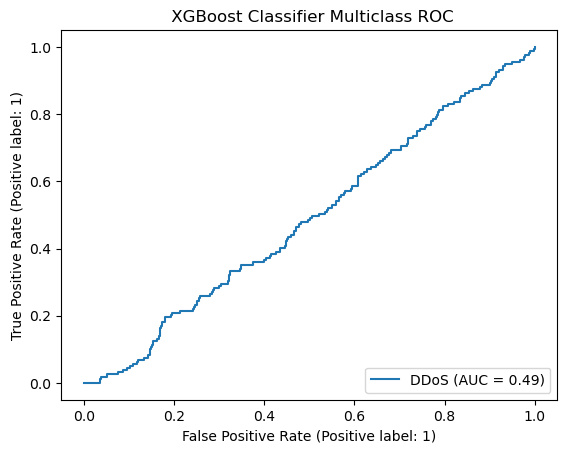

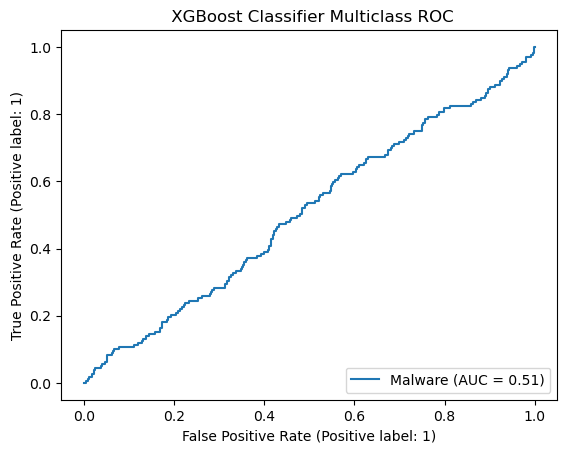

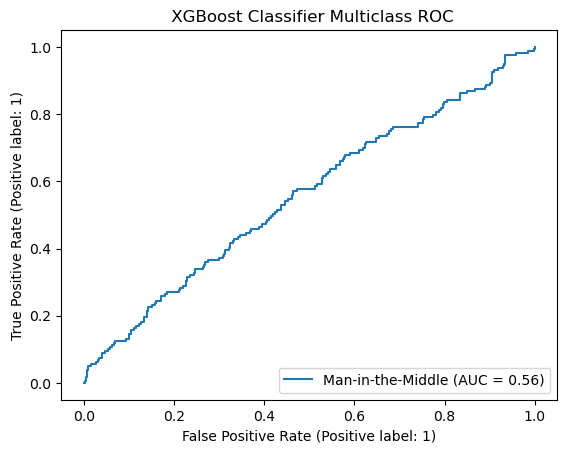

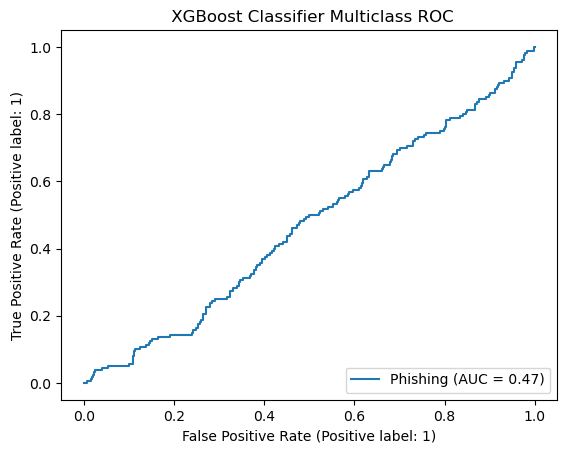

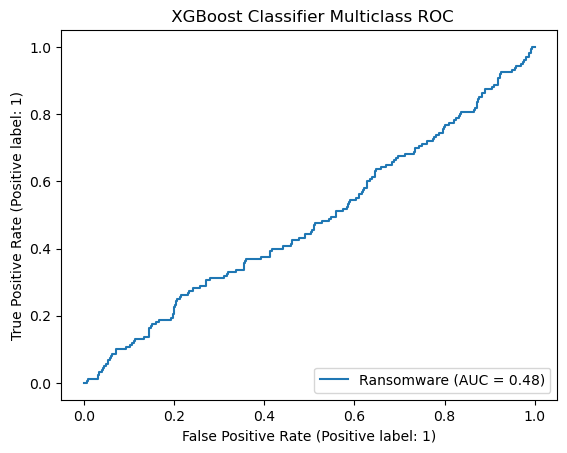

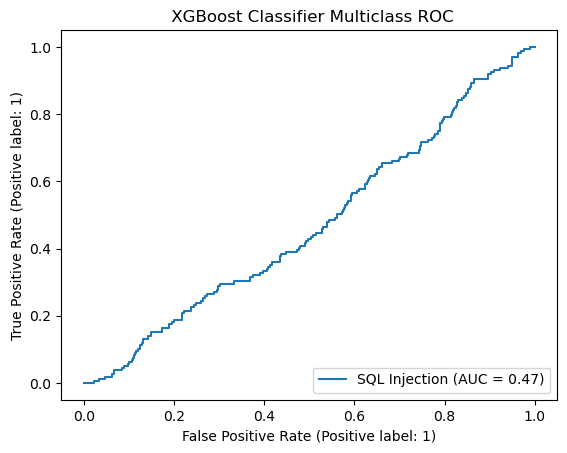

In [81]:
class_names = ["DDoS", "Malware", "Man-in-the-Middle", "Phishing", "Ransomware", "SQL Injection"]

y_pred = XGBst.predict(x_test)

print("Classification Report (XGB):")
print(classification_report(y_test, y_pred, target_names=class_names))

print("Confusion Matrix (XGB):")
print(confusion_matrix(y_test, y_pred))

y_test_bin = label_binarize(y_test, classes=XGBst.classes_)
y_score = XGBst.predict_proba(x_test)

for i, name in enumerate(class_names):
    RocCurveDisplay.from_predictions(y_test_bin[:, i], y_score[:, i], name=name)
    plt.title(" XGBoost Classifier Multiclass ROC")
    plt.show()

The XGBoost model achieved **17% accuracy**, which is slightly **below the 17.70% baseline**, indicating that it did not improve overall classification performance. Precision, recall, and F1-scores were generally low across all six attack classes, with macro and weighted averages of about **0.17**, showing weak and inconsistent multiclass detection. Among the classes, **Man-in-the-Middle** performed best with an **F1-score of 0.22** and the highest **AUC of 0.56**, while **Phishing** and **SQL Injection** were the weakest, each with an **AUC of 0.47**. Most ROC AUC values ranged only from **0.47 to 0.56**.

### Model Predictions

In [82]:
# Saving the model using .pkl
import joblib
joblib.dump(logr, "Cybersecurity Threat Analysis and Intrusion Detection.pki")

['Cybersecurity Threat Analysis and Intrusion Detection.pki']

#### Prediction On The Train Data

In [83]:
modelname = LogisticRegression()

In [84]:
# Training the model on the training data
modelname.fit(x_train, y_train)

LogisticRegression()

In [85]:
# loading the saved model and get the predictions
logr = joblib.load("Cybersecurity Threat Analysis and Intrusion Detection.pki")

# prediction
prediction = logr.predict(x_train)
prediction

array(['Malware', 'Man-in-the-Middle', 'Ransomware', ..., 'SQL Injection',
       'Phishing', 'Phishing'], dtype=object)

In [86]:
a = np.array(y_train)
df_Global_Cybersecurity_Threats_2015_2024_Dataset_train = pd.DataFrame()
df_Global_Cybersecurity_Threats_2015_2024_Dataset_train["predicted"] = prediction
df_Global_Cybersecurity_Threats_2015_2024_Dataset_train["original"] = a
df_Global_Cybersecurity_Threats_2015_2024_Dataset_train

,predicted,original
0,Malware,5
1,Man-in-the-Middle,2
2,Ransomware,2
3,Man-in-the-Middle,3
4,DDoS,3
...,...,...
2225,Man-in-the-Middle,2
2226,SQL Injection,3
2227,SQL Injection,4
2228,Phishing,5


**Prediction On The Test Data**

In [87]:
# Making predictions on the test data
predictions = logr.predict(x_test)

In [88]:
# diagnostics
print("raw shapes:", np.shape(predictions), np.shape(y_test))

raw shapes: (956,) (956,)


In [89]:
# convert predictions -> 1D labels
pred_arr = np.asarray(predictions)
if pred_arr.ndim == 2:
    # if probabilities (two columns), take class with highest score
    if pred_arr.shape[1] == 1:
        pred_arr = pred_arr.ravel()
    else:
        # common case: class probs for binary -> take positive class
        # adjust as needed: use argmax for multiclass
        pred_arr = np.argmax(pred_arr, axis=1)

preds = pred_arr.ravel()

In [90]:
# convert y_test -> 1D
if isinstance(y_test, pd.DataFrame):
    y_true = y_test.squeeze().values
else:
    y_true = np.asarray(y_test).ravel()

In [91]:
# check shapes
if preds.shape[0] != y_true.shape[0]:
    raise ValueError(f"Length mismatch: preds={preds.shape[0]} vs y_true={y_true.shape[0]}")

In [92]:
# final DataFrame
conclusion = pd.DataFrame({'Predicted': preds, 'Original': y_true})
print(conclusion.shape)
conclusion.head()

(956, 2)


,Predicted,Original
0,DDoS,3
1,DDoS,5
2,Phishing,5
3,DDoS,4
4,Ransomware,3


**Prediction On The Test Data**

In [93]:
# Make predictions on the test data
predictions = modelname.predict(x_test)

In [94]:
# diagnostics
print("raw shapes:", np.shape(predictions), np.shape(y_test))

raw shapes: (956,) (956,)


In [95]:
# convert predictions -> 1D labels
pred_arr = np.asarray(predictions)
if pred_arr.ndim == 2:
    # if probabilities (two columns), take class with highest score
    if pred_arr.shape[1] == 1:
        pred_arr = pred_arr.ravel()
    else:
        # common case: class probs for binary -> take positive class
        # adjust as needed: use argmax for multiclass
        pred_arr = np.argmax(pred_arr, axis=1)

preds = pred_arr.ravel()

In [96]:
# convert y_test -> 1D
if isinstance(y_test, pd.DataFrame):
    y_true = y_test.squeeze().values
else:
    y_true = np.asarray(y_test).ravel()

In [97]:
# check shapes
if preds.shape[0] != y_true.shape[0]:
    raise ValueError(f"Length mismatch: preds={preds.shape[0]} vs y_true={y_true.shape[0]}")

In [98]:
# final DataFrame
conclusion = pd.DataFrame({'Predicted': preds, 'Original': y_true})
print(conclusion.shape)
conclusion.head()

(956, 2)


,Predicted,Original
0,0,3
1,0,5
2,3,5
3,0,4
4,4,3


In [99]:
print(conclusion)

     Predicted  Original
0            0         3
1            0         5
2            3         5
3            0         4
4            4         3
..         ...       ...
951          5         5
952          0         0
953          4         5
954          4         1
955          3         2

[956 rows x 2 columns]


### Summary and Conclusion

**Project Summary**

This project explored the use of machine learning for **cybersecurity threat analysis and intrusion detection** using incident data from **2015 to 2024**. The main aim was to analyze historical cyberattack patterns and classify different threat categories such as DDoS, Malware, Man-in-the-Middle, Phishing, Ransomware, and SQL Injection. The dataset included attributes related to threat types, malware behavior, attack vectors, targeted sectors, countries of origin, and impact levels, making it suitable for threat intelligence and intrusion detection research. 

Several machine learning models were applied to evaluate their ability to classify cyber threats. Based on the attached results, **Logistic Regression** achieved the best overall performance with about **20% accuracy**, slightly above the **17.70% baseline**. **KNN** followed with **19% accuracy**, **Random Forest** achieved **18%**, and **XGBoost** performed weakest at **17%**, falling slightly below the baseline. Across the models, most precision, recall, F1-scores, and ROC AUC values remained low, with AUC values mostly close to **0.5**, showing weak class separability. The attached notebook also notes that Random Forest performed only marginally better than baseline, while **XGBoost** did not improve overall classification performance.   

**Project Conclusion**

The project shows that machine learning can be applied to cybersecurity incident data to identify patterns and attempt multiclass threat classification, but the current results indicate that the selected models were **not strong enough for reliable intrusion detection** in their present form. Although Logistic Regression slightly outperformed the other models, the improvement over baseline was small, and all models showed substantial class confusion and weak predictive discrimination. Overall, the findings suggest that the dataset likely contains overlapping attack characteristics that make multiclass classification difficult with basic modeling approaches.   

In conclusion, this project provides a useful foundation for cybersecurity threat analysis, but better performance will likely require stronger feature engineering, improved preprocessing, hyperparameter tuning, and possibly more advanced or hybrid models. Even so, the work is valuable because it highlights both the potential and the limitations of machine learning in real-world cyber threat detection and offers a clear direction for future improvement. 

### The End